<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/Baseline%20Reproduction/Reproduce_Baseline_QR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/QR_CNN_Project')

['QR_All_Malicious.zip', 'QR_All_benign.zip', 'QR_CNN.ipynb']

In [ ]:
!unzip -q "/content/drive/MyDrive/QR_CNN_Project/QR_All_benign.zip" -d "/content/qr_dataset"

In [ ]:
!unzip -q "/content/drive/MyDrive/QR_CNN_Project/QR_All_Malicious.zip" -d "/content/qr_dataset"

replace /content/qr_dataset/QR_All_Malicious/all_generated_urls_20251015_184324.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/qr_dataset/QR_All_Malicious/qrs/benign_000001.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!rm -rf /content/qr_dataset

!unzip -q "/content/drive/MyDrive/QR_CNN_Project/QR_All_benign.zip" -d "/content/qr_dataset"
!unzip -q "/content/drive/MyDrive/QR_CNN_Project/QR_All_Malicious.zip" -d "/content/qr_dataset"

replace /content/qr_dataset/QR_All_Malicious/all_generated_urls_20251015_184324.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
os.listdir('/content/qr_dataset')

['QR_All_Malicious', 'QR_All_benign']

In [ ]:
print('Benign')
print(os.listdir('/content/qr_dataset/QR_All_benign')[:10])
print('Malicious')
print(os.listdir('/content/qr_dataset/QR_All_Malicious')[:10])


Benign
['all_generated_urls_20251015_161937.csv', 'qrs']
Malicious
['qrs', 'all_generated_urls_20251015_184324.csv']


In [ ]:
BENIGN_DIR = "/content/qr_dataset/QR_All_benign/qrs"
MALICIOUS_DIR = "/content/qr_dataset/QR_All_Malicious/qrs"

benign_files = os.listdir(BENIGN_DIR)
malicious_files = os.listdir(MALICIOUS_DIR)

print("Benign images:", len(benign_files))
print("Malicious images:", len(malicious_files))

print("\nFirst benign files:")
print(benign_files[:5])

print("\nFirst malicious files:")
print(malicious_files[:5])

Benign images: 429976
Malicious images: 575762

First benign files:
['benign_184049.png', 'benign_419342.png', 'benign_147890.png', 'benign_385226.png', 'benign_211142.png']

First malicious files:
['benign_184049.png', 'benign_419342.png', 'benign_147890.png', 'benign_385226.png', 'benign_211142.png']


In [ ]:
benign_names = set(benign_files)
malicious_names = set(malicious_files)

common_names = benign_names.intersection(malicious_names)

print("Common names between benign and malicious file= ",len(common_names))
print(list(common_names)[:10])

Common names between benign and malicious file=  429976
['benign_289687.png', 'benign_291676.png', 'benign_025523.png', 'benign_008855.png', 'benign_375111.png', 'benign_410249.png', 'benign_175459.png', 'benign_414185.png', 'benign_353042.png', 'benign_293924.png']


In [ ]:
import hashlib

def md5(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

benign_path = "/content/qr_dataset/QR_All_benign/qrs/benign_123129.png"
malicious_path = "/content/qr_dataset/QR_All_Malicious/qrs/benign_123129.png"

print("Benign :", md5(benign_path))
print("Malicious:", md5(malicious_path))

Benign : a82462bd73ca7c8101ec154c597ff9ac
Malicious: 013561ede963656540b8ef82cac4778d


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

benign_dir = "/content/qr_dataset/QR_All_benign/qrs"
malicious_dir = "/content/qr_dataset/QR_All_Malicious/qrs"

valid_extensions = (".png")

benign_paths = [
    os.path.join(benign_dir, file_name)
    for file_name in os.listdir(benign_dir)
    if file_name.lower().endswith(valid_extensions)
]

malicious_paths = [
    os.path.join(malicious_dir, file_name)
    for file_name in os.listdir(malicious_dir)
    if file_name.lower().endswith(valid_extensions)
]

all_paths = np.array(benign_paths + malicious_paths)

all_labels = np.array(
    [0] * len(benign_paths) +
    [1] * len(malicious_paths)
)

print("Benign:", len(benign_paths))
print("Malicious:", len(malicious_paths))
print("Total:", len(all_paths))

Benign: 429976
Malicious: 575762
Total: 1005738


In [ ]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.20,
    random_state=42,
    stratify=all_labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 804590
Validation: 100574
Test: 100574


In [ ]:
import tensorflow as tf

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
# read images
def load_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=1
    )

    image.set_shape([None, None, 1])

    image = tf.image.resize(image, IMAGE_SIZE)

    image = tf.cast(image, tf.float32) / 255.0

    return image, tf.cast(label, tf.float32)

In [ ]:
def create_dataset(paths, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(paths), 10000),
            seed=42,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [ ]:
train_dataset = create_dataset(
    train_paths,
    train_labels,
    training=True
)

val_dataset = create_dataset(
    val_paths,
    val_labels
)

test_dataset = create_dataset(
    test_paths,
    test_labels
)

In [ ]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Image minimum:", tf.reduce_min(images).numpy())
    print("Image maximum:", tf.reduce_max(images).numpy())

Images shape: (32, 224, 224, 1)
Labels shape: (32,)
Image minimum: 0.0
Image maximum: 1.0


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        units=128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        units=1,
        activation="sigmoid"
    )
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,313 (427.00 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
project_dir = "/content/drive/MyDrive/QR_CNN"
os.makedirs(project_dir, exist_ok=True)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    BackupAndRestore
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/QR_CNN/best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

backup = BackupAndRestore(
    backup_dir="/content/drive/MyDrive/QR_CNN/training_backup"
)

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import time

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
   callbacks=[
        early_stopping,
        checkpoint,
        backup
    ]
)

end_time = time.time()

train_time = end_time - start_time

print(f"Training Time: {train_time:.2f} seconds")

Epoch 1/20
25144/25144 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6821 - loss: 0.5681
Epoch 1: val_loss improved from None to 0.40390, saving model to /content/drive/MyDrive/QR_CNN/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/QR_CNN/best_model.keras
25144/25144 ━━━━━━━━━━━━━━━━━━━━ 1299s 51ms/step - accuracy: 0.7474 - loss: 0.4926 - val_accuracy: 0.8088 - val_loss: 0.4039
Epoch 2/20
25144/25144 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8116 - loss: 0.4051
Epoch 2: val_loss improved from 0.40390 to 0.37180, saving model to /content/drive/MyDrive/QR_CNN/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/QR_CNN/best_model.keras
25144/25144 ━━━━━━━━━━━━━━━━━━━━ 1310s 50ms/step - accuracy: 0.8166 - loss: 0.3964 - val_accuracy: 0.8292 - val_loss: 0.3718
Epoch 3/20
25143/25144 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8292 - loss: 0.3746
Epoch 3: val_loss improved from 0.37180 to 0.36427, saving model to /content/drive/MyD

In [ ]:
import os

model_path = "/content/drive/MyDrive/QR_CNN/best_model.keras"
backup_path = "/content/drive/MyDrive/QR_CNN/training_backup"

print("Best model exists:", os.path.exists(model_path))
print("Backup folder exists:", os.path.exists(backup_path))

Best model exists: True
Backup folder exists: False


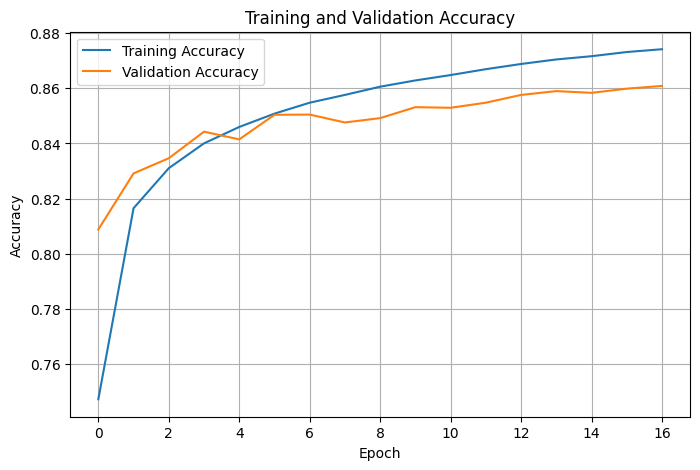

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

3143/3143 ━━━━━━━━━━━━━━━━━━━━ 98s 31ms/step - accuracy: 0.8570 - loss: 0.3227
3143/3143 ━━━━━━━━━━━━━━━━━━━━ 71s 22ms/step
Inference Time: 72.55 seconds
Test Loss: 0.3227
Accuracy:  0.8570
Precision: 0.8536
Recall:    0.8594
F1-score:  0.8553

Classification Report:
              precision    recall  f1-score   support

      Benign     0.8062    0.8761    0.8397     42997
   Malicious     0.9011    0.8427    0.8709     57577

    accuracy                         0.8570    100574
   macro avg     0.8536    0.8594    0.8553    100574
weighted avg     0.8605    0.8570    0.8576    100574



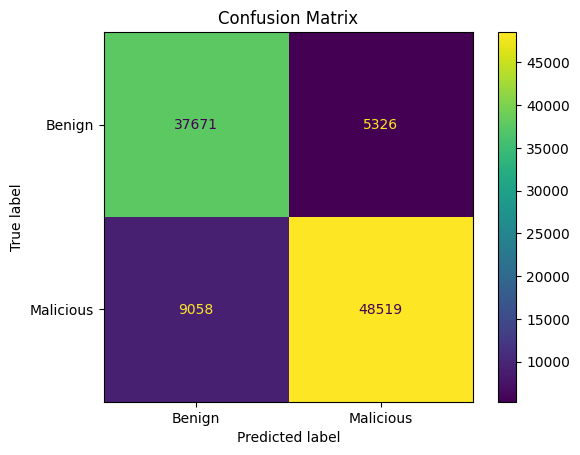

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

test_loss, test_accuracy = model.evaluate(test_dataset)

start_time = time.time()
y_prob = model.predict(test_dataset).ravel()

end_time = time.time()
inference_time = end_time - start_time

print(f"Inference Time: {inference_time:.2f} seconds")

y_pred = (y_prob >= 0.5).astype(int)

y_true = test_labels.astype(int)

cm = confusion_matrix(y_true, y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred,average="macro")
recall = recall_score(y_true, y_pred,average="macro")
f1 = f1_score(y_true, y_pred,average="macro")

print(f"Test Loss: {test_loss:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Benign", "Malicious"],
        digits=4
    )
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malicious"]
)

display.plot()
plt.title("Confusion Matrix")
plt.show()